<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/04_salmonellosis_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salmonellosis Machine Learning & Deep Learning

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [27]:
# sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn import set_config
set_config(transform_output='pandas')

## Custom Functions

In [3]:
# Model Evaluation Function
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mse ** 0.5
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  y_train_pred = reg.predict(X_train)

  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  y_test_pred = reg.predict(X_test)
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    results_df = results_df.set_index('Label')
    results_df.index.name=None
    return results_df.round(3)

## Load and Prepare Data

In [4]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [5]:
# Project folders
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

# Load the cleaned data created in the preparation notebook
cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17079 entries, 0 to 17078
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Reporting Area                     17079 non-null  object 
 1   Current MMWR Year                  17079 non-null  int64  
 2   MMWR WEEK                          17079 non-null  int64  
 3   Label                              17079 non-null  object 
 4   Current week                       17079 non-null  int64  
 5   Previous 52 week Max               17079 non-null  float64
 6   Cumulative YTD Current MMWR Year   17079 non-null  int64  
 7   Cumulative YTD Previous MMWR Year  17079 non-null  float64
 8   Season                             17079 non-null  object 
 9   Previous week cases                17079 non-null  float64
dtypes: float64(3), int64(4), object(3)
memory usage: 1.3+ MB


,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0


In [6]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

In [7]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
Reporting Area,0.409860
Current MMWR Year,0.029276
MMWR WEEK,0.310323
Label,0.005855
Current week,2.769483
Previous 52 week Max,4.209848
Cumulative YTD Current MMWR Year,18.923825
Cumulative YTD Previous MMWR Year,20.106564
Season,0.023421
Previous week cases,2.763628


In [8]:
# see columns and rows where NaN is present in df
df.isna().sum().sum()

np.int64(0)

In [9]:
df=df.drop(columns=['Label'])

## Feature Inspection

In [10]:
cat_cols=df.select_dtypes('object')
cat_cols.head(3)

,Reporting Area,Season
0,ALABAMA,Winter
1,ALABAMA,Winter
2,ALABAMA,Winter


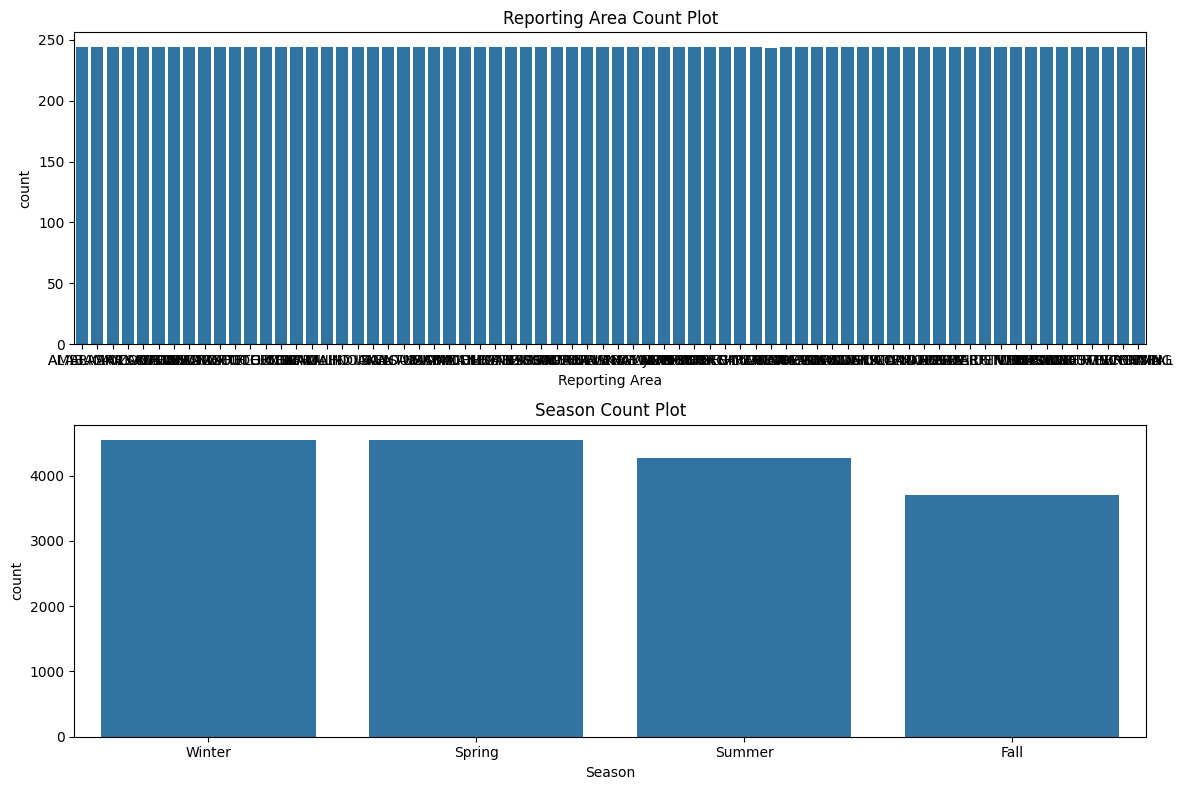

In [11]:
fig, axes = plt.subplots(2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # Temporary copy for visualization only
    temp = df[col].fillna("Missing")

    sns.countplot(x=temp, ax=axes[i])
    axes[i].set_title(f"{col} Count Plot")
    axes[i].set_xlabel(col)

plt.tight_layout()

In [12]:
num_cols=df.select_dtypes('number')
num_cols.head(3)

,Current MMWR Year,MMWR WEEK,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Previous week cases
0,2022,1,10,38.0,10,6.0,2.0
1,2022,2,3,38.0,18,12.0,10.0
2,2022,3,0,38.0,24,17.0,3.0


In [13]:
cnt=num_cols.columns
len(cnt)

7

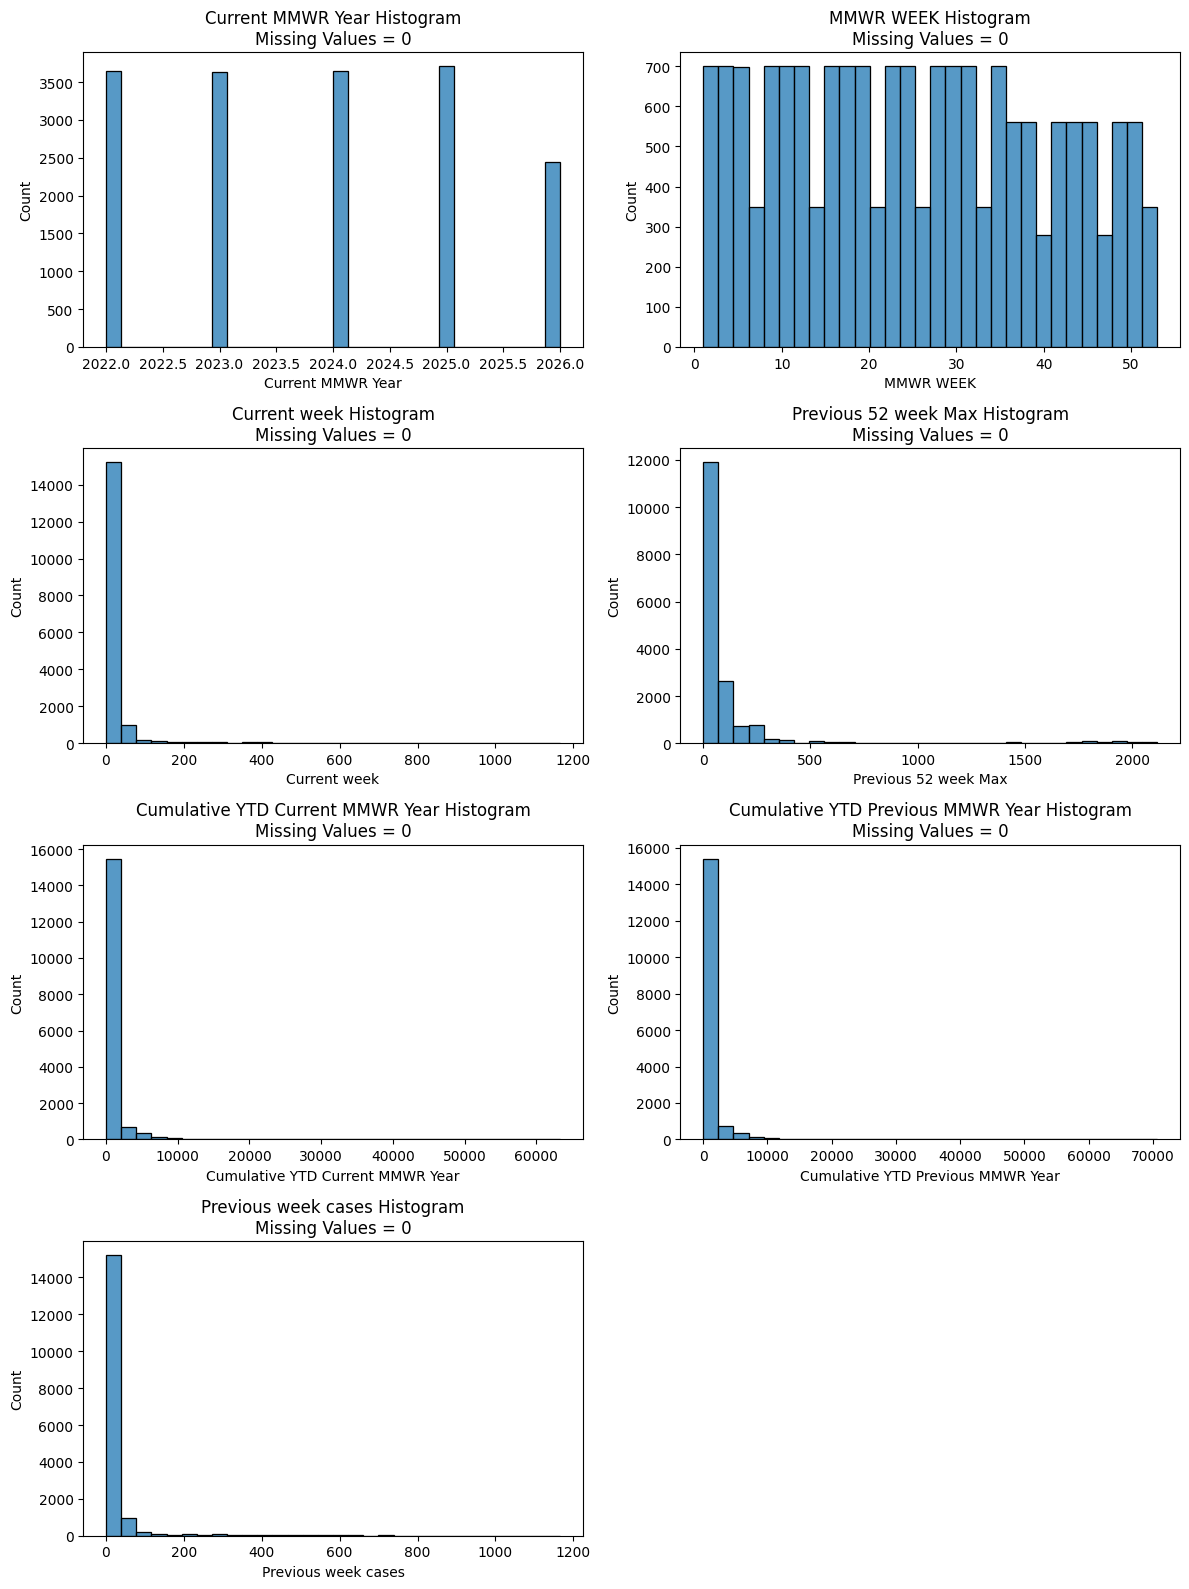

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    missing = df[col].isna().sum()

    sns.histplot(data=df, x=col, bins=30, ax=axes[i])

    axes[i].set_title(f"{col} Histogram\nMissing Values = {missing}")

# Remove the extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()

## EDA

In [15]:
df.head(3)

,Reporting Area,Current MMWR Year,MMWR WEEK,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,0,38.0,24,17.0,Winter,3.0


In [16]:
cat_cols

,Reporting Area,Season
0,ALABAMA,Winter
1,ALABAMA,Winter
2,ALABAMA,Winter
3,ALABAMA,Winter
4,ALABAMA,Winter
...,...,...
17074,WYOMING,Summer
17075,WYOMING,Summer
17076,WYOMING,Summer
17077,WYOMING,Summer


In [17]:
target = 'Current week'

categorical_cols = [
    'Season',
    "Current MMWR Year",
    "MMWR WEEK"
]

numerical_cols = df.select_dtypes('number').drop(columns=["Current MMWR Year", "MMWR WEEK"])

numerical_cols.head(3)

,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Previous week cases
0,10,38.0,10,6.0,2.0
1,3,38.0,18,12.0,10.0
2,0,38.0,24,17.0,3.0


In [18]:
len(categorical_cols)

3

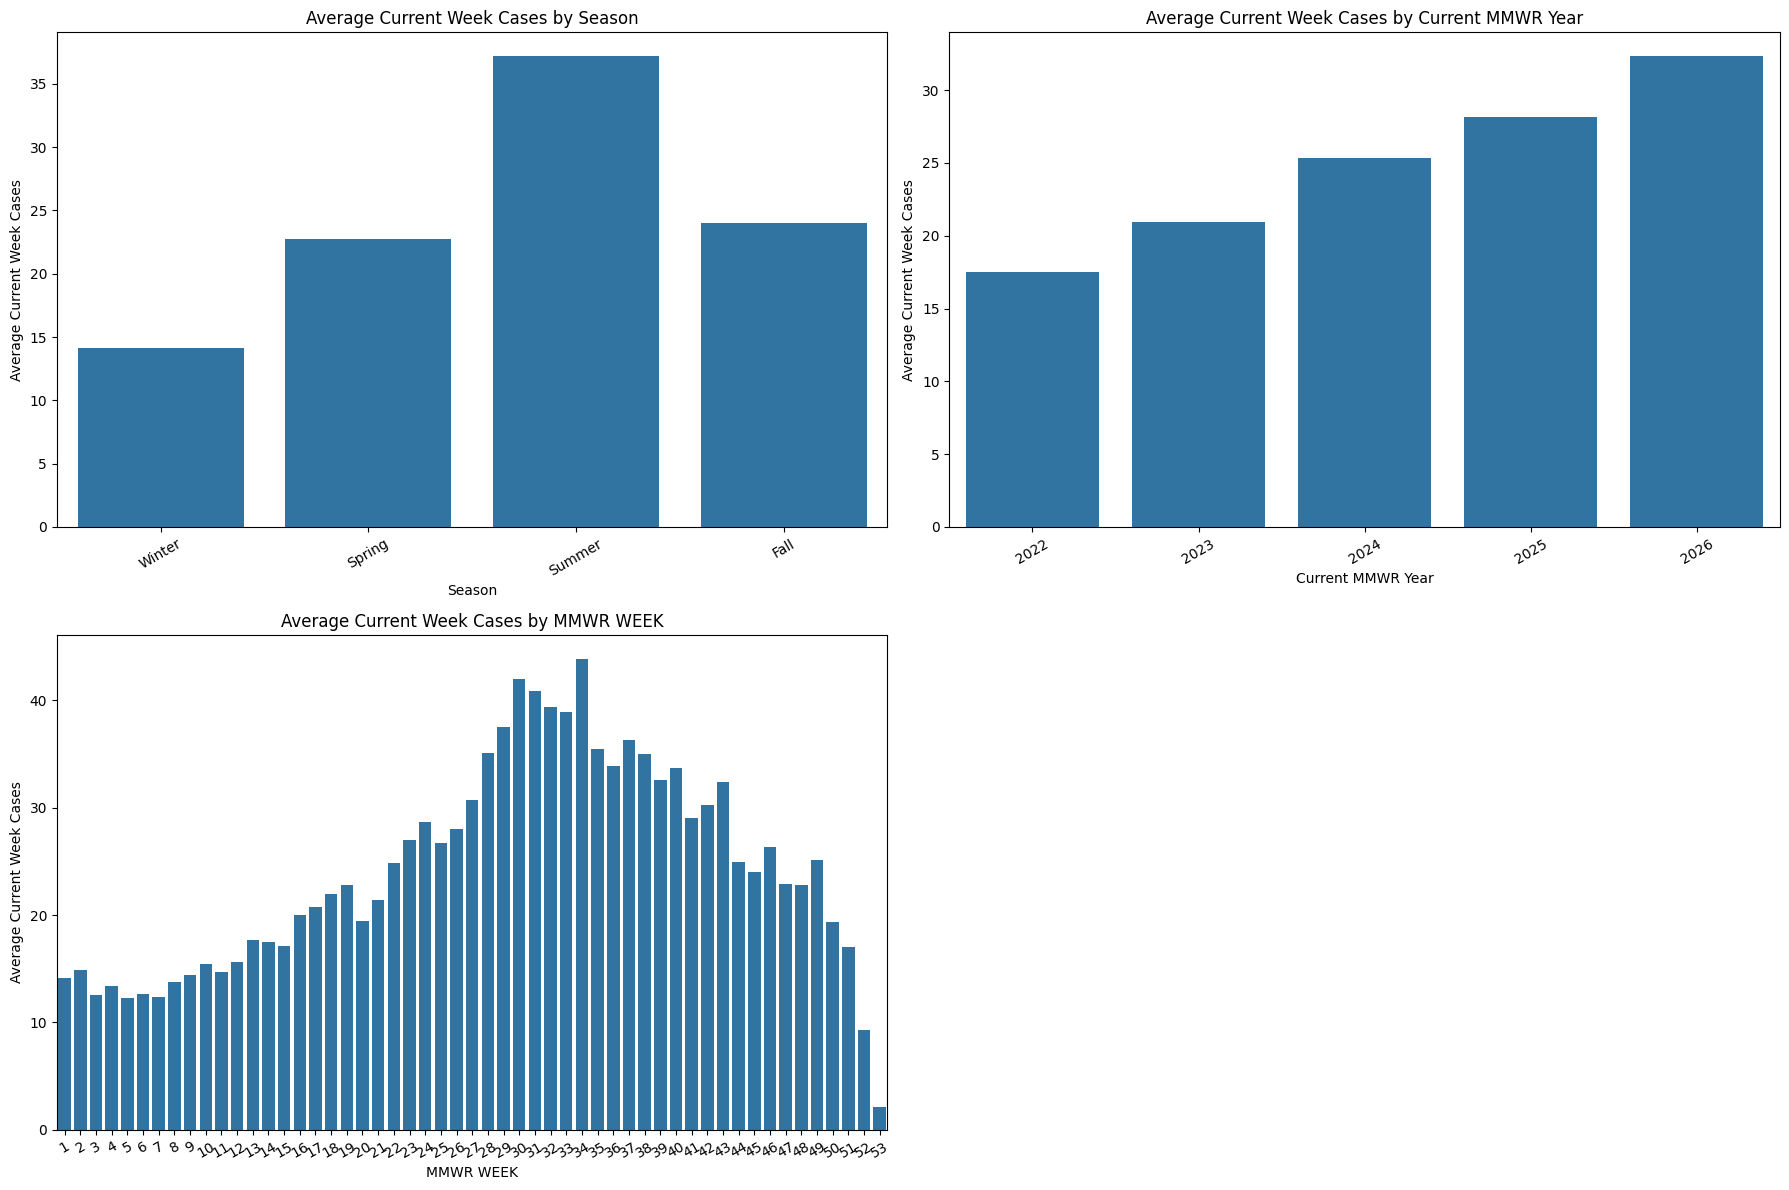

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    sns.barplot(
        data=df,
        x=col,
        y="Current week",
        estimator="mean",
        errorbar=None,
        ax=axes[i]
    )

    axes[i].set_title(f"Average Current Week Cases by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Average Current Week Cases")
    axes[i].tick_params(axis="x", rotation=30)

# Remove unused subplots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

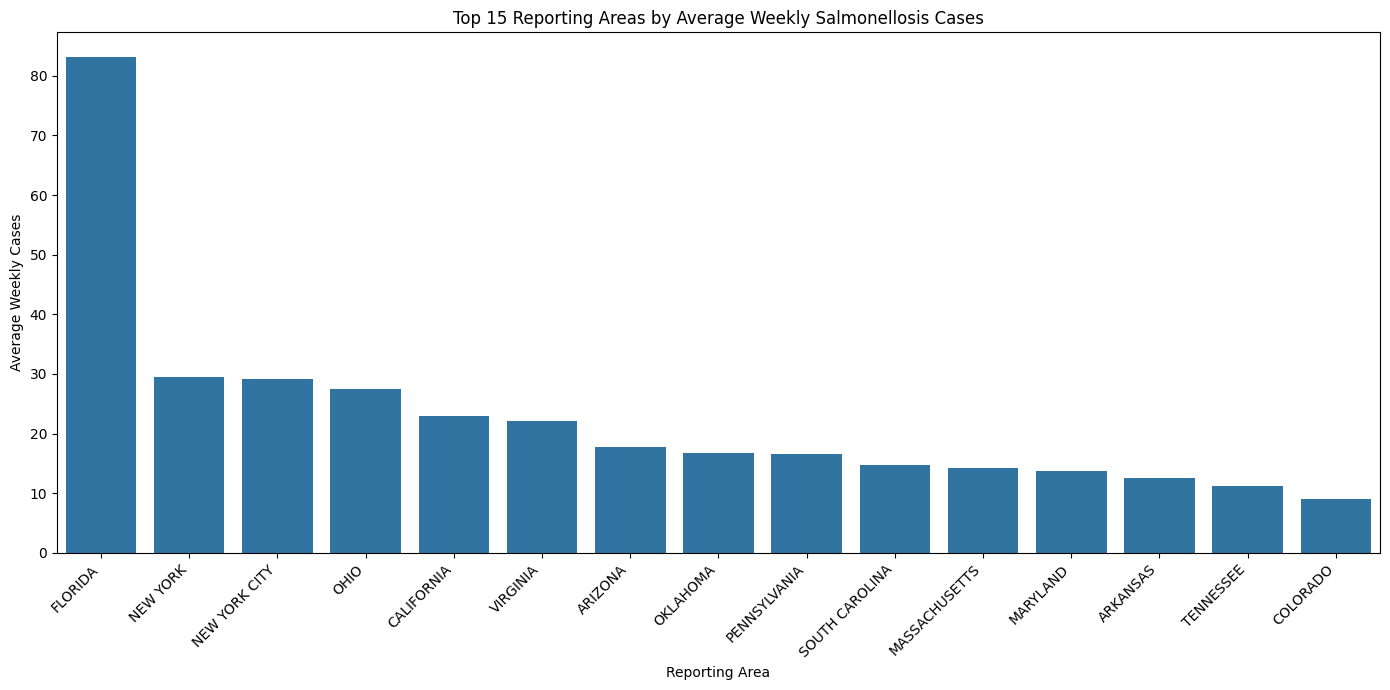

In [20]:
# National and regional totals to remove
areas_to_remove = [
    "TOTAL",
    "US RESIDENTS",
    "US TERRITORIES",
    "NON-US RESIDENTS",
    "NEW ENGLAND",
    "MIDDLE ATLANTIC",
    "EAST NORTH CENTRAL",
    "WEST NORTH CENTRAL",
    "SOUTH ATLANTIC",
    "EAST SOUTH CENTRAL",
    "WEST SOUTH CENTRAL",
    "MOUNTAIN",
    "PACIFIC"
]

# Keep only individual reporting areas
state_df = df[
    ~df["Reporting Area"].isin(areas_to_remove)
].copy()

# Find top 15 areas by average weekly cases
top_15_areas = (
    state_df
    .groupby("Reporting Area")["Current week"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Keep only top 15
top_15_df = state_df[
    state_df["Reporting Area"].isin(top_15_areas)
]

# Plot
plt.figure(figsize=(14, 7))

sns.barplot(
    data=top_15_df,
    x="Reporting Area",
    y="Current week",
    estimator="mean",
    errorbar=None,
    order=top_15_areas
)

plt.title("Top 15 Reporting Areas by Average Weekly Salmonellosis Cases")
plt.xlabel("Reporting Area")
plt.ylabel("Average Weekly Cases")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

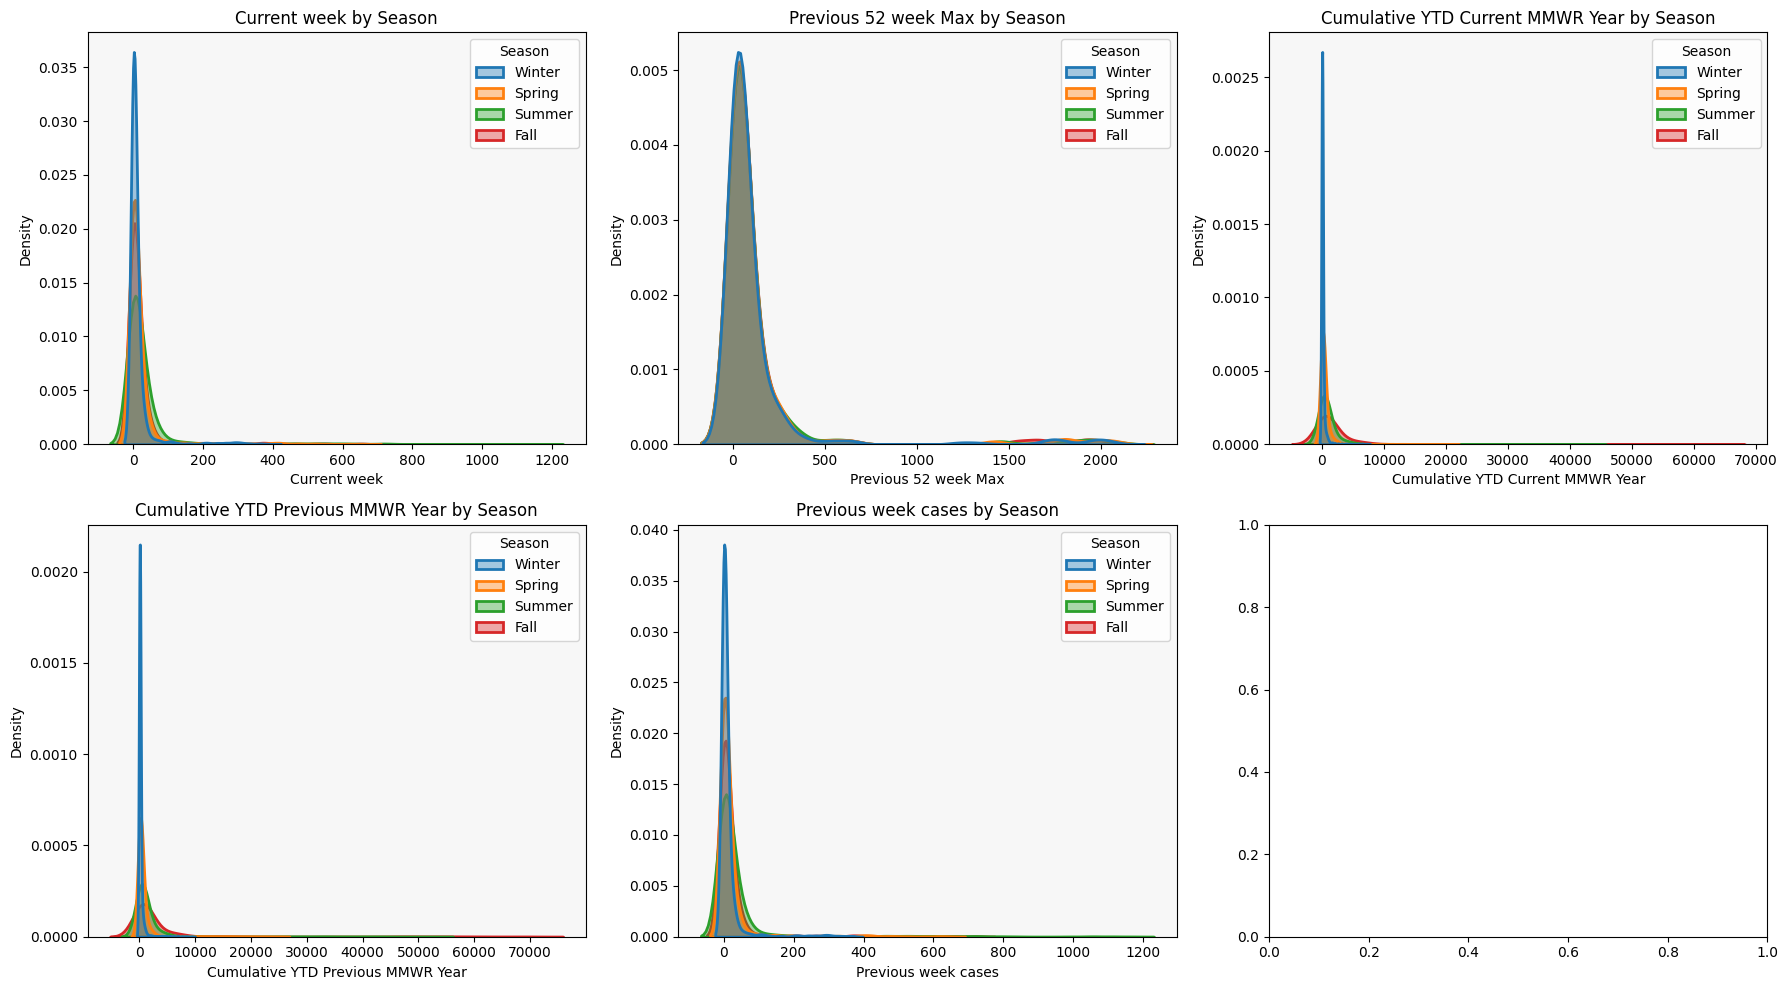

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):

    subset = df[[feature, "Season"]].dropna()

    sns.kdeplot(
        data=subset,
        x=feature,
        hue="Season",
        common_norm=False,
        fill=True,
        alpha=0.4,
        linewidth=2,
        ax=axes[i]
    )

    axes[i].set_title(f"{feature} by Season")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")
    axes[i].set_facecolor("#f7f7f7")

# Remove unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

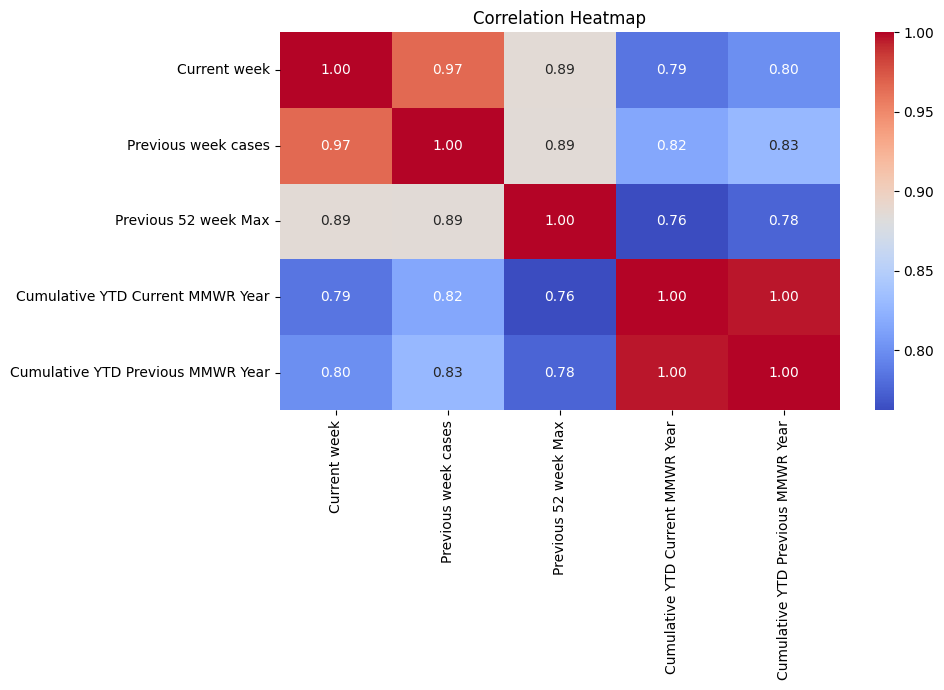

In [22]:
# Create a copy for correlation analysis
df_corr = df.copy()

# Numerical columns that are meaningful for correlation
corr_cols = [
    "Current week",
    "Previous week cases",
    "Previous 52 week Max",
    "Cumulative YTD Current MMWR Year",
    "Cumulative YTD Previous MMWR Year"
]

# Keep only the selected numerical columns
df_corr = df_corr[corr_cols]

# Calculate correlations
corr = df_corr.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The correlation heatmap shows strong relationships between several numerical features. The two cumulative YTD variables are almost perfectly correlated, indicating multicollinearity. One of these features should be removed before modeling to avoid redundant information.

## Preprocess

In [23]:
# Target
target = "Current week"

y = df[target]

# Features
X = df.drop(columns=[
    target,
    "Cumulative YTD Previous MMWR Year"  # drop due to very high multicollinearity
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [30]:
# Categorical columns
categorical_cols = [
    "Reporting Area",
    "Season"
]

ohe_tuple = (
    "Categorical",
    OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore",
        drop="first"
    ),
    categorical_cols
)


# Numerical columns
numeric_cols = [
    "Previous week cases",
    "Previous 52 week Max",
    "Cumulative YTD Current MMWR Year"
]

num_tuple = (
    "Numeric",
    StandardScaler(),
    numeric_cols
)


# Combine preprocessing
preprocessor = ColumnTransformer(
    [
        num_tuple,
        ohe_tuple
    ],
    verbose_feature_names_out=False
)

<Axes: >

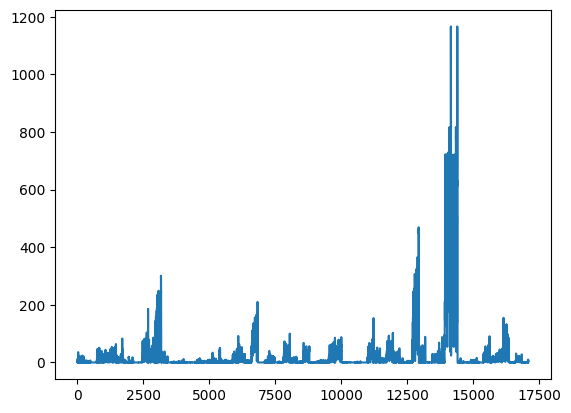

In [24]:
df[target].plot()

In [25]:
X_train.head()

,Reporting Area,Current MMWR Year,MMWR WEEK,Previous 52 week Max,Cumulative YTD Current MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,38.0,10,Winter,2.0
1,ALABAMA,2022,2,38.0,18,Winter,10.0
2,ALABAMA,2022,3,38.0,24,Winter,3.0
3,ALABAMA,2022,4,38.0,26,Winter,0.0
4,ALABAMA,2022,5,38.0,29,Winter,2.0


## Model: Linear Regression

* try a default model and then gridsearch
* use evaluate regression function
evaluate_regression(MODEL, X_train, y_train, X_test, y_test)

In [33]:
lr_model = make_pipeline(
    preprocessor,
    LinearRegression()
)

lr_model.fit(X_train, y_train)

evaluate_regression(lr_model, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 5.565
- MSE = 179.448
- RMSE = 13.396
- R^2 = 0.815

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 17.766
- MSE = 1,863.389
- RMSE = 43.167
- R^2 = 0.933


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [34]:
param_grid = {
    "linearregression__fit_intercept": [True, False]
}

grid_lr = GridSearchCV(
    lr_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error")

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)

evaluate_regression(
    grid_lr.best_estimator_,
    X_train, y_train,
    X_test, y_test)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Best Parameters: {'linearregression__fit_intercept': True}
------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 5.565
- MSE = 179.448
- RMSE = 13.396
- R^2 = 0.815

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 17.766
- MSE = 1,863.389
- RMSE = 43.167
- R^2 = 0.933


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Model: Random Forest

* try a default model and then gridsearch

In [35]:
rf_model = make_pipeline(
    preprocessor,
    RandomForestRegressor(random_state=42)
)

rf_model.fit(X_train, y_train)

evaluate_regression(
    rf_model,
    X_train, y_train,
    X_test, y_test
)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.860
- MSE = 27.164
- RMSE = 5.212
- R^2 = 0.972

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 23.272
- MSE = 4,936.866
- RMSE = 70.263
- R^2 = 0.821


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [37]:
param_grid = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [None, 10, 20]
}

grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

evaluate_regression(
    grid_rf.best_estimator_,
    X_train, y_train,
    X_test, y_test)

Best Parameters: {'randomforestregressor__max_depth': 10, 'randomforestregressor__n_estimators': 100}
------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 3.875
- MSE = 62.938
- RMSE = 7.933
- R^2 = 0.935

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 23.657
- MSE = 5,102.780
- RMSE = 71.434
- R^2 = 0.815


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Explanatory Data Analysis

* keep emmpty dont touch from here till down

## Final Model

## Neural Network